In [37]:
import pandas as pd

df = pd.read_csv("../data/raw/predictive_maintenance.csv")
df = pd.get_dummies(df, columns=["Type"], drop_first=True)
df = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])

X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

df.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
# Applying criteria of higher penalty to misclassifying failures and lower penalty for non-failures.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [40]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000

ROC-AUC: 0.9068855803190842


In [41]:
# Using Random Forest Classifier with class_weight="balanced" to handle class imbalance.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.94      0.47      0.63        68

    accuracy                           0.98      2000
   macro avg       0.96      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.71      0.74        68

    accuracy                           0.98      2000
   macro avg       0.89      0.85      0.87      2000
weighted avg       0.98      0.98      0.98      2000


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.60      0.78      0.68        68

    accuracy                           0.97      2000
   macro avg       0.79      0.88      0.83      2000
weighted avg       0.98   

In [42]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.94      0.47      0.63        68

    accuracy                           0.98      2000
   macro avg       0.96      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9632276823772989


In [43]:
# Logistic regression is predicting many more failures and Random forest is predicting failures more conservatively with higher precision

In [44]:
# Default threshold (0.5) was too conservative
# Evaluated multiple thresholds
# Selected 0.3 as best trade-off

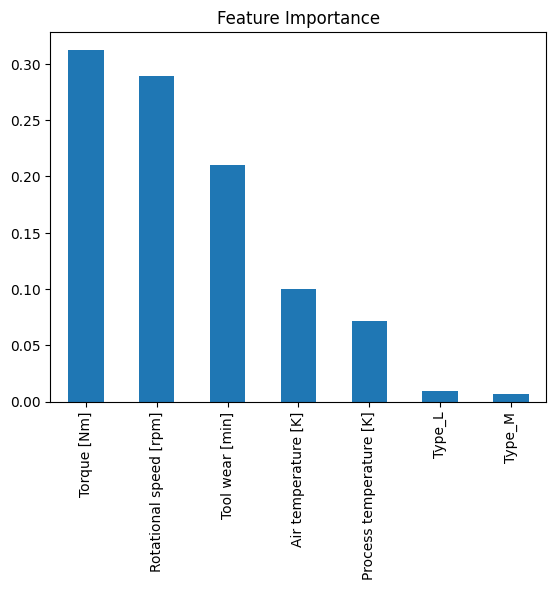

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [46]:
# The model identified torque, rotational speed, and tool wear as the most influential features for predicting machine failure. This suggests that failure is driven primarily by mechanical stress and accumulated degradation, rather than static machine characteristics. Temperature features also contribute, indicating the role of thermal conditions in accelerating wear.

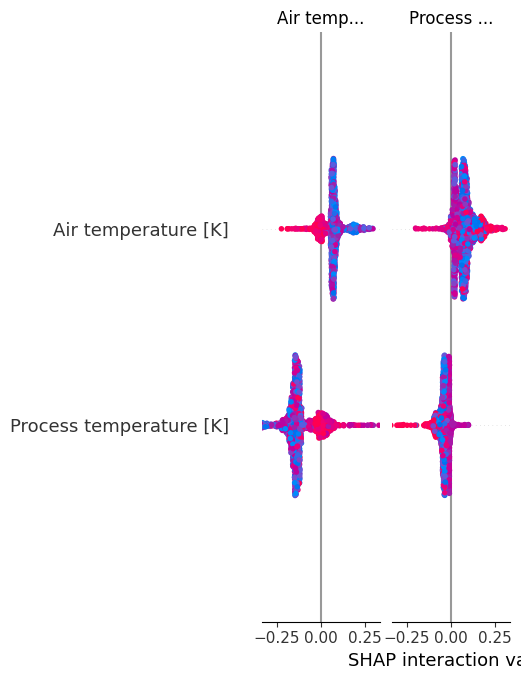

In [47]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [48]:
# SHAP analysis confirmed that high torque and tool wear consistently increase failure probability, demonstrating that the model captures physically meaningful degradation patterns.

In [49]:
import joblib

joblib.dump(model, "../models/random_forest_model.joblib")

['../models/random_forest_model.joblib']